<h1>M2: Data & EDA Report</h1>

<h3>Import Libaries</h3>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



<h3>1. Dataset Description & Schema Summary</h3>

<b>Primary Dataset:</b><br/>
The is the Electric Vehicle Population Data (2025) obtained from the Washington State Department of Licensing via Data.gov(https://catalog.data.gov/dataset/electric-vehicle-population-data ).

In [2]:
#Load the dataset 1
df1 = pd.read_csv("Electric_Vehicle_Population_Data.csv")

In [3]:
print(df1.head(5))
print(df1.dtypes)
print(f"Total rows: {df1.shape[0]}")
print(f"Total columns: {df1.shape[1]}")

   VIN (1-10)     County        City State  Postal Code  Model Year    Make  \
0  5YJ3E1EBXJ     Yakima      Yakima    WA      98902.0        2018   TESLA   
1  1N4BZ0CP2G       King        Kent    WA      98030.0        2016  NISSAN   
2  1C4JJXP64P  Snohomish  Marysville    WA      98271.0        2023    JEEP   
3  WA1E2AFY0S  Snohomish     Bothell    WA      98012.0        2025    AUDI   
4  1N4AZ0CPXG       King     Seattle    WA      98125.0        2016  NISSAN   

      Model                   Electric Vehicle Type  \
0   MODEL 3          Battery Electric Vehicle (BEV)   
1      LEAF          Battery Electric Vehicle (BEV)   
2  WRANGLER  Plug-in Hybrid Electric Vehicle (PHEV)   
3      Q5 E  Plug-in Hybrid Electric Vehicle (PHEV)   
4      LEAF          Battery Electric Vehicle (BEV)   

  Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0           Clean Alternative Fuel Vehicle Eligible           215.0   
1           Clean Alternative Fuel Vehicle Eligible 

The dataset contains 276828 records and 16 variables f registered Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs). Key variables include ZIP code, vehicle type, make, model year, electric range, and registration count. The dataset provides statewide coverage across Washington ZIP codes.

<b>Secondory Dataset:</b><br/>
Supplementary data include population size , median age by ZIP code , median person income and household income obtained from Data Commons using U.S. Census–derived indicators using Data download tool at https://datacommons.org/tools/download.

In [4]:
#Load the dataset 2
df2 = pd.read_csv("Washington_CensusZipCodeTabulationArea.csv")

In [5]:
print(df2.head(5))
print(df2.dtypes)
print(f"Total rows: {df2.shape[0]}")
print(f"Total columns: {df2.shape[1]}")

   placeDcid  placeName  Date:Count_Person  Value:Count_Person  \
0  zip/98001      98001               2023               36041   
1  zip/98002      98002               2023               37284   
2  zip/98003      98003               2023               52210   
3  zip/98004      98004               2023               39435   
4  zip/98005      98005               2023               21929   

                                 Source:Count_Person  Date:Median_Age_Person  \
0  https://www.census.gov/programs-surveys/acs/da...                  2023.0   
1  https://www.census.gov/programs-surveys/acs/da...                  2023.0   
2  https://www.census.gov/programs-surveys/acs/da...                  2023.0   
3  https://www.census.gov/programs-surveys/acs/da...                  2023.0   
4  https://www.census.gov/programs-surveys/acs/da...                  2023.0   

   Value:Median_Age_Person                           Source:Median_Age_Person  \
0                     39.9  https://www.c

The dataset 2 contains 583 records and 14 variables.This dataset provides ZIP code–level information on population, median age, and median household income.

<h3>2. Data Cleaning & Preprocessing Steps</h3>

<b>Loading data</b> </br>
The 2 datasets were merged using ZIP code as the common geographic identifier. Here the left join will be perform that all electric vehicle records from Dataset 1 are preserved, even if corresponding demographic information is missing in Dataset 2.

In [6]:
# Rename (must assign back)
df1 = df1.rename(columns={'Postal Code': 'zip_code'})
df2 = df2.rename(columns={'placeName': 'zip_code'})

# Standardize zip_code as 5 char string
df1['zip_code'] = df1['zip_code'].astype('string').str.replace(r'\.0$', '', regex=True).str.zfill(5)
df2['zip_code'] = df2['zip_code'].astype('string').str.replace(r'\.0$', '', regex=True).str.zfill(5)

# Left join (df1 is primary)
df = df1.merge(df2, on='zip_code', how='left')

<b>Inspecting raw data</b>

In [7]:
df.head()

,VIN (1-10),County,City,State,zip_code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,...,Source:Count_Person,Date:Median_Age_Person,Value:Median_Age_Person,Source:Median_Age_Person,Date:Median_Income_Person,Value:Median_Income_Person,Source:Median_Income_Person,Date:Median_Income_Household,Value:Median_Income_Household,Source:Median_Income_Household
0,5YJ3E1EBXJ,Yakima,Yakima,WA,98902,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,https://www.census.gov/programs-surveys/acs/da...,2023.0,34.7,https://www.census.gov/programs-surveys/acs/da...,2023.0,34717.0,https://www.census.gov/programs-surveys/acs/da...,2023.0,60050.0,https://www.census.gov/programs-surveys/acs/da...
1,1N4BZ0CP2G,King,Kent,WA,98030,2016,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,https://www.census.gov/programs-surveys/acs/da...,2023.0,35.3,https://www.census.gov/programs-surveys/acs/da...,2023.0,43017.0,https://www.census.gov/programs-surveys/acs/da...,2023.0,91218.0,https://www.census.gov/programs-surveys/acs/da...
2,1C4JJXP64P,Snohomish,Marysville,WA,98271,2023,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,https://www.census.gov/programs-surveys/acs/da...,2023.0,39.3,https://www.census.gov/programs-surveys/acs/da...,2023.0,48199.0,https://www.census.gov/programs-surveys/acs/da...,2023.0,97547.0,https://www.census.gov/programs-surveys/acs/da...
3,WA1E2AFY0S,Snohomish,Bothell,WA,98012,2025,AUDI,Q5 E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,https://www.census.gov/programs-surveys/acs/da...,2023.0,35.9,https://www.census.gov/programs-surveys/acs/da...,2023.0,65254.0,https://www.census.gov/programs-surveys/acs/da...,2023.0,141653.0,https://www.census.gov/programs-surveys/acs/da...
4,1N4AZ0CPXG,King,Seattle,WA,98125,2016,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,https://www.census.gov/programs-surveys/acs/da...,2023.0,37.8,https://www.census.gov/programs-surveys/acs/da...,2023.0,56493.0,https://www.census.gov/programs-surveys/acs/da...,2023.0,96725.0,https://www.census.gov/programs-surveys/acs/da...


In [8]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276828 entries, 0 to 276827
Data columns (total 29 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         276828 non-null  object 
 1   County                                             276813 non-null  object 
 2   City                                               276813 non-null  object 
 3   State                                              276828 non-null  object 
 4   zip_code                                           276813 non-null  string 
 5   Model Year                                         276828 non-null  int64  
 6   Make                                               276828 non-null  object 
 7   Model                                              276828 non-null  object 
 8   Electric Vehicle Type                              276828 non-null  object

<b>After looking at data overview, All column names to standized with the lowercase with "_" improves consistency, prevents coding errors, and makes the data easier to manage and read.</b>

In [9]:
df.columns = (
    df.columns
    .str.strip()                      
    .str.lower()                     
    .str.replace(" ", "_")            
    .str.replace("-", "_")           
    .str.replace(r"[^\w_]", "", regex=True)  #
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276828 entries, 0 to 276827
Data columns (total 29 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   vin_1_10                                         276828 non-null  object 
 1   county                                           276813 non-null  object 
 2   city                                             276813 non-null  object 
 3   state                                            276828 non-null  object 
 4   zip_code                                         276813 non-null  string 
 5   model_year                                       276828 non-null  int64  
 6   make                                             276828 non-null  object 
 7   model                                            276828 non-null  object 
 8   electric_vehicle_type                            276828 non-null  object 
 9   clean_alternati

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276828 entries, 0 to 276827
Data columns (total 29 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   vin_1_10                                         276828 non-null  object 
 1   county                                           276813 non-null  object 
 2   city                                             276813 non-null  object 
 3   state                                            276828 non-null  object 
 4   zip_code                                         276813 non-null  string 
 5   model_year                                       276828 non-null  int64  
 6   make                                             276828 non-null  object 
 7   model                                            276828 non-null  object 
 8   electric_vehicle_type                            276828 non-null  object 
 9   clean_alternati

<b>Rename the columns to manage and reproduce easier in the further analysis</b>

In [11]:
df = df.rename(columns={'vin_1_10': 'vinno'
                        ,'clean_alternative_fuel_vehicle_cafv_eligibility': 'cafv_eligibility'
                        ,'valuecount_person': 'population'
                        ,'valuemedian_age_person': 'median_age'
                        ,'valuemedian_income_person': 'median_income_person'
                        ,'valuemedian_income_household': 'median_income_household'})

df.info()
print(f"Total rows: {df.shape[0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276828 entries, 0 to 276827
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   vinno                          276828 non-null  object 
 1   county                         276813 non-null  object 
 2   city                           276813 non-null  object 
 3   state                          276828 non-null  object 
 4   zip_code                       276813 non-null  string 
 5   model_year                     276828 non-null  int64  
 6   make                           276828 non-null  object 
 7   model                          276828 non-null  object 
 8   electric_vehicle_type          276828 non-null  object 
 9   cafv_eligibility               276828 non-null  object 
 10  electric_range                 276820 non-null  float64
 11  legislative_district           276141 non-null  float64
 12  dol_vehicle_id                

<b>Remove the duplicate records</b>

In [12]:
df = df.drop_duplicates()
print(f"Total rows: {df.shape[0]}")

Total rows: 276828


No dupliate records found.

<b>Drop columns that are not relevant to the analysis</b><br/>These columns were removed because they mostly contain technical details like source information, dates, or  location ref codes that are not needed for analyzing EV adoption and income patterns.

In [13]:
df = df.drop(columns=['legislative_district','2020_census_tract', 'placedcid', 'datecount_person','sourcecount_person','datemedian_age_person','sourcemedian_age_person','datemedian_income_person','sourcemedian_income_person','datemedian_income_household','sourcemedian_income_household'])

<b>Handling Missing Values</b>

In [14]:
#check null value
df.isna().sum()

vinno                         0
county                       15
city                         15
state                         0
zip_code                     15
model_year                    0
make                          0
model                         0
electric_vehicle_type         0
cafv_eligibility              0
electric_range                8
dol_vehicle_id                0
vehicle_location             99
electric_utility             15
population                 8992
median_age                 9007
median_income_person       9007
median_income_household    9015
dtype: int64

About 9,000+ records have missing values for median household income, so they cannot be used in the analysis and need to be removed. Since ZIP code is the key geographic variable for this study, records with missing ZIP-related income data were dropped to ensure accurate and reliable results.

In [15]:
df = df.dropna(subset=['median_income_household'])
print(df.isna().sum())
print(f"Total rows: {df.shape[0]}")
df.info()

vinno                      0
county                     0
city                       0
state                      0
zip_code                   0
model_year                 0
make                       0
model                      0
electric_vehicle_type      0
cafv_eligibility           0
electric_range             8
dol_vehicle_id             0
vehicle_location           0
electric_utility           0
population                 0
median_age                 0
median_income_person       0
median_income_household    0
dtype: int64
Total rows: 267813
<class 'pandas.core.frame.DataFrame'>
Index: 267813 entries, 0 to 276827
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   vinno                    267813 non-null  object 
 1   county                   267813 non-null  object 
 2   city                     267813 non-null  object 
 3   state                    267813 non-null  object 
 4   zip_c

<b>Correcting Data Types</b>

In [16]:
#Population should be whole numbers

df['population'] = df['population'].astype('Int64')

#Convert median_income to Integer

df['median_income_household'] = df['median_income_household'].astype('Int64')
df['median_income_person'] = df['median_income_person'].astype('Int64')

#convert cateogrial values to reduce memory and analysis cleaner
categorical_cols = [
    'county','city','state','make','model',
    'electric_vehicle_type','cafv_eligibility','electric_utility'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

The first and last characters of the VIN number were masked to protect sensitive vehicle identification information while retaining partial structure for reference.

In [17]:
df['vinno'] = df['vinno'].apply(
    lambda x: 'X' + str(x)[1:-1] + 'X' if pd.notnull(x) and len(str(x)) > 2 else x
)

In [18]:
print(f"Total rows: {df.shape[0]}")
df.info()

Total rows: 267813
<class 'pandas.core.frame.DataFrame'>
Index: 267813 entries, 0 to 276827
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   vinno                    267813 non-null  object  
 1   county                   267813 non-null  category
 2   city                     267813 non-null  category
 3   state                    267813 non-null  category
 4   zip_code                 267813 non-null  string  
 5   model_year               267813 non-null  int64   
 6   make                     267813 non-null  category
 7   model                    267813 non-null  category
 8   electric_vehicle_type    267813 non-null  category
 9   cafv_eligibility         267813 non-null  category
 10  electric_range           267805 non-null  float64 
 11  dol_vehicle_id           267813 non-null  int64   
 12  vehicle_location         267813 non-null  object  
 13  electric_utility         26781

In [19]:
df.head()

,vinno,county,city,state,zip_code,model_year,make,model,electric_vehicle_type,cafv_eligibility,electric_range,dol_vehicle_id,vehicle_location,electric_utility,population,median_age,median_income_person,median_income_household
0,XYJ3E1EBXX,Yakima,Yakima,WA,98902,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,131356970,POINT (-120.51904 46.59783),PACIFICORP,45377,34.7,34717,60050
1,XN4BZ0CP2X,King,Kent,WA,98030,2016,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,211702123,POINT (-122.19975 47.37483),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),38492,35.3,43017,91218
2,XC4JJXP64X,Snohomish,Marysville,WA,98271,2023,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,238694900,POINT (-122.17138 48.10433),PUGET SOUND ENERGY INC,30561,39.3,48199,97547
3,XA1E2AFY0X,Snohomish,Bothell,WA,98012,2025,AUDI,Q5 E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,28.0,278444183,POINT (-122.20105 47.84423),PUGET SOUND ENERGY INC,76123,35.9,65254,141653
4,XN4AZ0CPXX,King,Seattle,WA,98125,2016,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,252437846,POINT (-122.30253 47.72656),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),43807,37.8,56493,96725


<b>Clean data for further Analysis</b> </br>
Unnecessary vehicle-level variables such as VIN, model details, and location identifiers were removed to focus the analysis on geographic and adoption-level factors. The dataset was then grouped by ZIP code and electric vehicle type to calculate the total number of EVs per category within each ZIP area.

In [20]:
df_clean = df.drop(columns=[
    'vinno','model','make','model_year',
    'electric_range','cafv_eligibility',
    'dol_vehicle_id','vehicle_location'
])

#EvCount
ev_counts = (
    df.groupby(['zip_code', 'electric_vehicle_type'], observed=True)
      .size()
      .reset_index(name='ev_count')
)



zip_demo = (
    df[['zip_code','county','city','state',
        'population','median_age','median_income_person','median_income_household']]
    .drop_duplicates(subset=['zip_code'])
)



df_clean = zip_demo.merge(ev_counts, on='zip_code', how='left')

#  Calculate EV adoption rate
df_clean['ev_adoption_rate'] = (
    df_clean['ev_count'] / df_clean['population']
)



df_clean.head()


,zip_code,county,city,state,population,median_age,median_income_person,median_income_household,electric_vehicle_type,ev_count,ev_adoption_rate
0,98902,Yakima,Yakima,WA,45377,34.7,34717,60050,Battery Electric Vehicle (BEV),204,0.004496
1,98902,Yakima,Yakima,WA,45377,34.7,34717,60050,Plug-in Hybrid Electric Vehicle (PHEV),85,0.001873
2,98030,King,Kent,WA,38492,35.3,43017,91218,Battery Electric Vehicle (BEV),793,0.020602
3,98030,King,Kent,WA,38492,35.3,43017,91218,Plug-in Hybrid Electric Vehicle (PHEV),154,0.004001
4,98271,Snohomish,Marysville,WA,30561,39.3,48199,97547,Battery Electric Vehicle (BEV),552,0.018062


<h3>3. Exploratory Data Analysis (EDA)</h3>

<b>Histrogram - No. of EV Distribution</b>

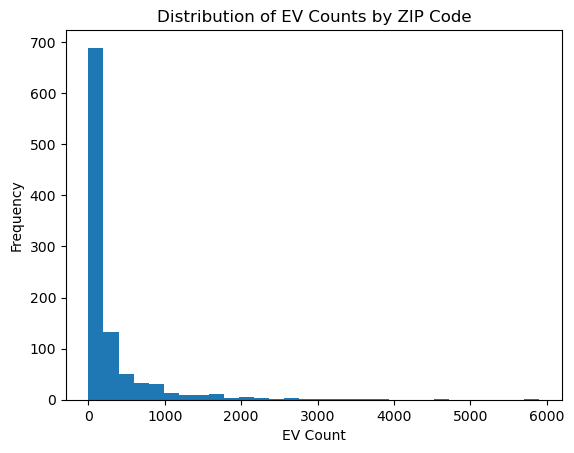

In [21]:
plt.hist(df_clean['ev_count'], bins=30)
plt.title("Distribution of EV Counts by ZIP Code")
plt.xlabel("EV Count")
plt.ylabel("Frequency")
plt.show()

The histogram indicates a heavily right-skewed distribution, with the majority of ZIP codes exhibiting low EV counts and a small number of ZIP codes accounting for disproportionately high concentrations of electric vehicles.

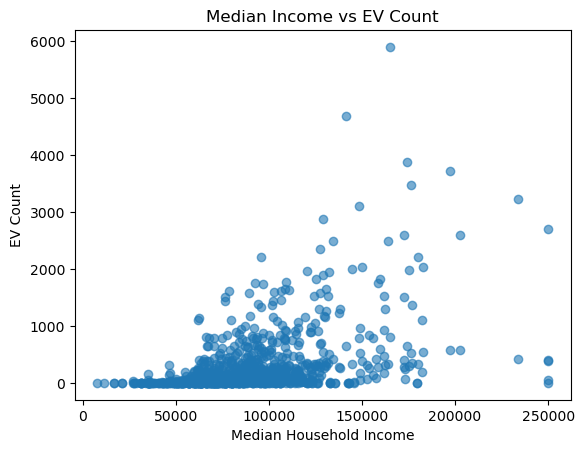

In [22]:
plt.scatter(df_clean['median_income_household'],
            df_clean['ev_count'], alpha=0.6)

plt.xlabel("Median Household Income")
plt.ylabel("EV Count")
plt.title("Median Income vs EV Count")
plt.show()

The scatterplot suggests a positive relationship between median income and EV count, meaning higher-income ZIP codes tend to have more registered electric vehicles.

<b>Boxplot – EV Count by Electric Vehicle Type</b>

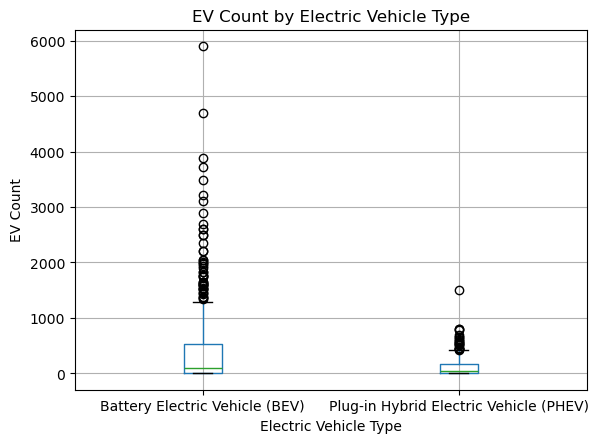

In [23]:
df_clean.boxplot(column='ev_count', by='electric_vehicle_type')

plt.title("EV Count by Electric Vehicle Type")
plt.suptitle("")   # removes automatic subtitle
plt.xlabel("Electric Vehicle Type")
plt.ylabel("EV Count")
plt.show()

The boxplot shows differences in EV count distribution between Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs). BEVs generally exhibit higher median counts and greater variability across ZIP codes, suggesting stronger adoption of fully electric vehicles compared to hybrid models.

<b>Correlation Heatmap</b>

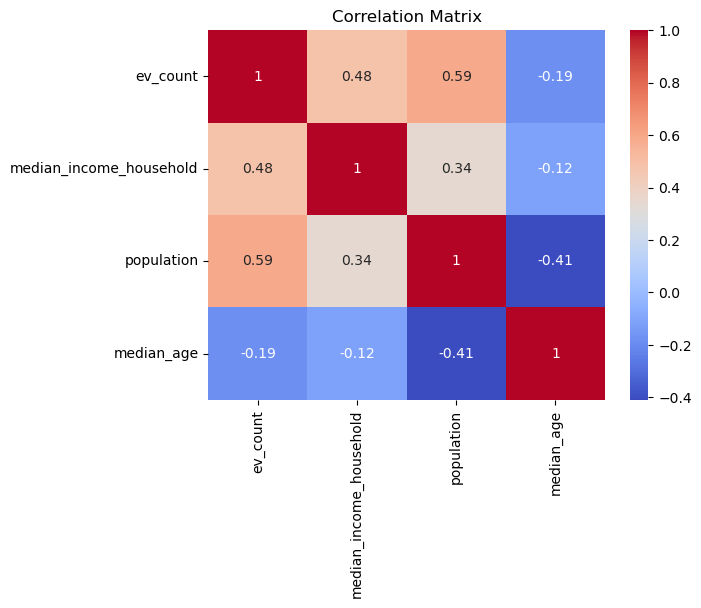

In [24]:
corr_vars = [
    'ev_count',
    'median_income_household',
    'population',
    'median_age'
]

sns.heatmap(df_clean[corr_vars].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

Median household income and population show positive correlation with EV counts. Median age may exhibit a weaker relationship. These findings support further regression modeling.

The EDA analysis reveals meaningful variation in EV adoption across ZIP codes in Washington State. Higher-income and higher-population areas appear associated with greater EV presence. The observed patterns suggest that socioeconomic factors play an important role in electric vehicle adoption, justifying further statistical modeling.

<h3>4. Ethical, De-identification, & Data Quality Concerns</h3>

<ul>
  <li><strong>Sensitive fields removed or masked</strong>
    <ul>
      <li>VIN numbers were intially masked to reduce privacy risk to visualize the clean data.</li>
      <li>Vehicle ID and detailed location fields were removed.</li>
      <li>These fields were not needed for the research question,so removed later</li>
    </ul>
  </li>

  <li><strong>Handling of quasi-identifiers</strong>
    <ul>
      <li>ZIP code was kept because it is required for geographic analysis.</li>
      <li>Analysis was done at the ZIP-code level, not the individual level.</li>
      <li>No names, dates of birth, or personal income data were included.</li>
    </ul>
  </li>

  <li><strong>Possible sources of bias</strong>
    <ul>
      <li>EV adoption may reflect income and charging access, not only consumer preference.</li>
      <li>Urban and higher-income areas may be overrepresented.</li>
      <li>Rural or lower-income communities may appear underrepresented.</li>
    </ul>
  </li>

  <li><strong>Missing data issues</strong>
    <ul>
      <li>Records with missing median household income were removed.</li>
      <li>This may slightly reduce coverage for some ZIP codes.</li>
    </ul>
  </li>

  <li><strong>Dataset limitations</strong>
    <ul>
      <li>ZIP-level data may hide inequality within the same area.</li>
      <li>EV registration does not always mean the vehicle is actively used.</li>
      <li>Charging infrastructure data is not included in this dataset.</li>
      <li>Census-based estimates may include small measurement errors.</li>
    </ul>
  </li>

  <li><strong>Ethical considerations from EDA</strong>
    <ul>
      <li>Lower EV adoption should not be interpreted as lack of awareness or effort.</li>
      <li>Results show statistical association, not causation.</li>
    </ul>
  </li>

  <li><strong>Identifiable information</strong>
    <ul>
      <li>The final dataset contains no direct personal identifiers.</li>
      <li>All analysis uses aggregated ZIP-level data, so privacy risk is minimal.</li>
    </ul>
  </li>
</ul>
